In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import time
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

#prereq = "para trabajar pre req progv22025-09-15095342_procesado.xlsx"
#historial = "detalle matricula cohorte 2019.xlsx"
historial = "historia_todos.csv"

                                

In [7]:
def calcular_num_intentos(df: pd.DataFrame) -> pd.DataFrame:
    # Paso 1: quedarse con intentos únicos por periodo
    df_unique = df[['Pidm', 'Cod materia curso', 'Periodo']].drop_duplicates()

    # Paso 2: ordenar por periodo
    df_unique = df_unique.sort_values(['Pidm', 'Cod materia curso', 'Periodo'])

    # Paso 3: generar número de intento acumulado
    # rank(method='dense') da consecutivos (1,2,3..) por periodo distinto
    df_unique['num_intentos_asignatura'] = (
        df_unique.groupby(['Pidm', 'Cod materia curso']).cumcount() + 1
    )

    # Paso 4: hacer merge con el dataframe original
    df_result = df.merge(
        df_unique,
        on=['Pidm', 'Cod materia curso', 'Periodo'],
        how='left'
    )

    return df_result

In [8]:
## Funciones de limpieza del DataFrame

def arreglar_comas_por_puntos(df: pd.DataFrame, cols_excluir: list) -> pd.DataFrame:
    """
    Reemplaza comas (,) por puntos (.) en todas las columnas tipo string,
    excepto en las columnas listadas en cols_excluir.
    Intenta convertir los valores resultantes a float.
    """
    for col in df.columns:
        if col not in cols_excluir and df[col].dtype == object:
            df[col] = df[col].str.replace(",", ".", regex=False)
            # Intentar conversión a float cuando sea posible
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass  # si no se puede convertir, se queda como string
            print(f"[Comas→Puntos] Procesada columna: {col}")
        elif col in cols_excluir:
            print(f"[Comas→Puntos] Columna excluida: {col}")
    return df


def imputar_valores(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores en columnas específicas."""
    # Columna repitencia → vacíos a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        despues = df[col_repitencia].isna().sum()
        print(f"[Imputación] Columna '{col_repitencia}': {antes} vacíos reemplazados por 0.0")

    # Columna Procedencia Categoria → reemplazar "6 No registra" por NaN
    col_procedencia = "_ Matricula detalle para analisis.Procedencia Categoria"
    if col_procedencia in df.columns:
        conteo = (df[col_procedencia] == "6 No registra").sum()
        df[col_procedencia] = df[col_procedencia].replace("6 No registra", np.nan)
        print(f"[Imputación] Columna '{col_procedencia}': {conteo} valores '6 No registra' reemplazados por NaN")

    # Columna Sexo → reemplazar -99 por NaN
    col_sexo = "_ Matricula detalle para analisis.Sexo"
    if col_sexo in df.columns:
        conteo = (df[col_sexo] == -99).sum()
        df[col_sexo] = df[col_sexo].replace(-99, np.nan)
        print(f"[Imputación] Columna '{col_sexo}': {conteo} valores '-99' reemplazados por NaN")

    # Columna Calificacion_Final → vacíos a -1
    col_nota_final = "Calificacion_Final"
    if col_nota_final in df.columns:
        conteo = df[col_nota_final].isna().sum()
        df[col_nota_final] = df[col_nota_final].fillna(-1).astype(float)
        print(f"[Imputación] Columna '{col_nota_final}': {conteo} vacíos reemplazados por -1")

    # Añadir columna de numero de intentos asignatura
    df = calcular_num_intentos(df)
    print(f"[Imputación] Columna num_intentos_asignatura': usando funcion calcular_num_intentos")

    return df


def eliminar_columnas_vacias(df: pd.DataFrame, columnas_eliminadas: list) -> pd.DataFrame:
    """Elimina columnas 100% vacías."""
    cols_vacias = df.columns[df.isna().all()].tolist()
    if cols_vacias:
        df = df.drop(columns=cols_vacias)
        columnas_eliminadas.extend(cols_vacias)
        print(f"[Columnas] Eliminadas columnas vacías: {cols_vacias}")
    else:
        print("[Columnas] No se encontraron columnas totalmente vacías")
    return df


def eliminar_filas_por_columna(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Elimina filas con nulos en columnas con <20% vacíos."""
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total


def limpiar_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Función principal que limpia el dataframe según reglas definidas."""
    print("=== Iniciando limpieza del DataFrame ===")

    # Imputación de valores
    df = imputar_valores(df)

    # Eliminar columnas vacías
    columnas_eliminadas = []
    df = eliminar_columnas_vacias(df, columnas_eliminadas)

    # Eliminar filas según condición por columnas
    df, filas_eliminadas = eliminar_filas_por_columna(df)

    # Resumen final
    print("\n=== Resumen limpieza ===")
    print(f"Filas eliminadas: {filas_eliminadas}")
    print(f"Columnas eliminadas: {columnas_eliminadas}")
    print(f"Total filas a considerar: {len(df)}")

    return df


In [9]:
## Calcular promedio resultado de pre requisitos

def obtener_columnas_prereq(df: pd.DataFrame):
    """Identifica las columnas que comienzan con 'Prereq' y las organiza por atributo."""
    prereq_cols = [c for c in df.columns if c.startswith("Prereq")]
    
    col_notas = [c for c in prereq_cols if c.endswith("_Nota")]
    col_intentos = [c for c in prereq_cols if c.endswith("_Intentos")]
    col_cadena = [c for c in prereq_cols if c.endswith("_EsCadena")]
    
    return col_notas, col_intentos, col_cadena


def calcular_promedios(df: pd.DataFrame, col_notas, col_intentos, col_cadena):
    """
    Calcula los promedios de notas e intentos en tres categorías:
    general, directos y cadenas.
    """
    # --- General ---
    df["prom_prereq_nota_general"] = df[col_notas].mean(axis=1, skipna=True)
    df["prom_prereq_intentos_general"] = df[col_intentos].mean(axis=1, skipna=True)

    # --- Directos ---
    notas_directos = []
    intentos_directos = []

    for i in range(1, len(col_notas) + 1):
        col_nota = f"Prereq_{i}_Nota"
        col_intento = f"Prereq_{i}_Intentos"
        col_es_cadena = f"Prereq_{i}_EsCadena"
        
        if col_nota in df.columns and col_es_cadena in df.columns:
            mask_directo = df[col_es_cadena] != "VERDADERO"
            notas_directos.append(df[col_nota].where(mask_directo))
        if col_intento in df.columns and col_es_cadena in df.columns:
            mask_directo = df[col_es_cadena] != "VERDADERO"
            intentos_directos.append(df[col_intento].where(mask_directo))

    if notas_directos:
        df["prom_prereq_nota_directos"] = pd.concat(notas_directos, axis=1).mean(axis=1, skipna=True)
    else:
        df["prom_prereq_nota_directos"] = np.nan

    if intentos_directos:
        df["prom_prereq_intentos_directos"] = pd.concat(intentos_directos, axis=1).mean(axis=1, skipna=True)
    else:
        df["prom_prereq_intentos_directos"] = np.nan

    # --- Cadenas ---
    notas_cadena = []
    intentos_cadena = []

    for i in range(1, len(col_notas) + 1):
        col_nota = f"Prereq_{i}_Nota"
        col_intento = f"Prereq_{i}_Intentos"
        col_es_cadena = f"Prereq_{i}_EsCadena"
        
        if col_nota in df.columns and col_es_cadena in df.columns:
            mask_cadena = df[col_es_cadena] == "VERDADERO"
            notas_cadena.append(df[col_nota].where(mask_cadena))
        if col_intento in df.columns and col_es_cadena in df.columns:
            mask_cadena = df[col_es_cadena] == "VERDADERO"
            intentos_cadena.append(df[col_intento].where(mask_cadena))

    if notas_cadena:
        df["prom_prereq_nota_cadena"] = pd.concat(notas_cadena, axis=1).mean(axis=1, skipna=True)
    else:
        df["prom_prereq_nota_cadena"] = np.nan

    if intentos_cadena:
        df["prom_prereq_intentos_cadena"] = pd.concat(intentos_cadena, axis=1).mean(axis=1, skipna=True)
    else:
        df["prom_prereq_intentos_cadena"] = np.nan

    return df

def acumular_resultado_requisitos(df: pd.DataFrame):
    """
    Calcula promedios de notas e intentos de prerequisitos.
    Devuelve:
      - df1: DataFrame original + columnas de promedios
      - df2: DataFrame sin columnas originales de prerequisitos pero con columnas nuevas
    """
    print("=== Iniciando acumulación de prerequisitos ===")

    # Identificar columnas relevantes
    col_notas, col_intentos, col_cadena = obtener_columnas_prereq(df)
    print(f"[Prereq] Identificadas {len(col_notas)} columnas de notas y {len(col_intentos)} columnas de intentos")

    # Calcular promedios
    df1 = df.copy()
    df1 = calcular_promedios(df1, col_notas, col_intentos, col_cadena)

    # Crear versión sin prereqs pero con nuevas columnas
    cols_prereq = [c for c in df.columns if c.startswith("Prereq")]
    df2 = df1.drop(columns=cols_prereq)

    print("[Prereq] Columnas nuevas añadidas: ",
          ["prom_prereq_nota_general", "prom_prereq_intentos_general",
           "prom_prereq_nota_directos", "prom_prereq_intentos_directos",
           "prom_prereq_nota_cadena", "prom_prereq_intentos_cadena"])

    return df1, df2



In [10]:
#Renombrar Columnas

def renombrar_columnas(df: pd.DataFrame):
    """
    Renombra columnas largas por versiones cortas en snake_case.
    Devuelve:
      - DataFrame con columnas renombradas
      - Lista con columnas finales de análisis (col_usar renombradas)
      - String con el nombre de la variable objetivo renombrada
    """

    # Mapeo de nombres originales a nuevos
    mapping = {
        "_ Matricula detalle para analisis.repitencia profesor referencia": "repitencia_prof_ref",
        "Nombre_Programa": "programa",
        "Cod materia curso": "asignatura",
        "DPTO Asignatura": "Dpto_Asignatura",
        "_ Matricula detalle para analisis.Prof_Codigo": "profesor_codigo",
        "_ Matricula detalle para analisis.pga inicial": "pga_inicial",
        "_ Matricula detalle para analisis.prom semestral t_1": "promedio_sem_t1",
        "_ Matricula detalle para analisis.Sexo": "sexo",
        "_ Matricula detalle para analisis.Asistencia CREE t_1": "asistencia_cree_t1",
        "_ Matricula detalle para analisis.Procedencia Categoria": "procedencia_categoria",
        "_ Matricula detalle para analisis.Edad cursan asignatura": "edad_curso",
        "_ Matricula detalle para analisis.Calif Final _ Retiros": "resultado_final"
    }

    # Renombrar columnas
    df = df.rename(columns=mapping)

    # Construir lista final de columnas de análisis
    col_usar = [
        "repitencia_prof_ref",
        "programa",
        "asignatura",
        "Dpto_Asignatura",
        'prom_prereq_nota_directos', 'prom_prereq_intentos_directos', 'prom_prereq_nota_cadena', 'prom_prereq_intentos_cadena',
        "profesor_codigo",
        "pga_inicial", "promedio_sem_t1",
        "sexo",
        "asistencia_cree_t1",
        "procedencia_categoria",
        "edad_curso",
        "num_intentos_asignatura"
    ]

    # Variable objetivo
    var_objetivo = "resultado_final"

    return df, col_usar, var_objetivo


In [11]:
#Cambiar a category

def cambiar_a_category(df, cols):
    # Convierte columnas a category si existen

    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
        else:
            print(f"Columna no encontrada: {c}")

    # Verificar tipos resultantes
    print(df[ [c for c in cols if c in df.columns] ].dtypes)  

    return df


    

In [20]:
# Entrenar_xgboost_regresion

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

def entrenar_xgboost_regresion(df, columna_objetivo, columnas_predictores):
    """
    Entrena un modelo XGBoost de regresión sobre un dataframe.

    Parámetros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada

    Retorna:
        modelo (XGBRegressor): Modelo entrenado
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Definir modelo
    #modelo = XGBRegressor(
    #    objective="reg:squarederror",
    #    enable_categorical=True,
    #    random_state=42
    #)

     # Definir modelo con hiperparámetros iniciales
    modelo = XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42,
    subsample=0.8,
    reg_lambda=3,
    reg_alpha=0.01,
    n_estimators=800,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.8
    )

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predicciones en test
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R2": r2}

    # Mostrar métricas como tabla
    print("\n📊 Métricas de evaluación del modelo:\n")
    print(pd.DataFrame(metricas, index=["Valores"]).T)

    # Agregar columna de predicciones al df
    df_resultados = df.copy()
    df_resultados["Prediccion_XGB"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test


In [13]:
# mostrar_arbol & mostrar_importancia_gain & reporte_importancia

from xgboost import plot_tree
import matplotlib.pyplot as plt
from xgboost import plot_importance

def mostrar_arbol(modelo, num_tree=0, ancho=40, alto=20, orientacion="LR"):
    """
    Muestra el árbol de decisión generado por XGBoost.

    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        num_tree (int): Índice del árbol a graficar
        ancho (int): Ancho de la figura
        alto (int): Alto de la figura
        orientacion (str): Dirección del árbol ("LR"=izq-der, "TB"=arriba-abajo)
    """
    plt.figure(figsize=(ancho, alto))
    plot_tree(modelo, num_trees=num_tree, rankdir=orientacion)
    plt.show()


def mostrar_importancia_gain(modelo, top_n=20):
    """
    Muestra la importancia de las variables en el modelo.
    
    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        top_n (int): Número de variables a mostrar
    """
    plt.figure(figsize=(10,6))
    plot_importance(modelo, importance_type="gain", max_num_features=top_n, height=0.5)
    plt.title("Importancia de variables (gain)")
    plt.show()


def reporte_importancia(modelo):
    """
    Genera un reporte tabulado de importancia de variables
    con métricas: gain, weight y cover.
    """
    booster = modelo.get_booster()

    # Obtener cada métrica como diccionario
    importancia_gain = booster.get_score(importance_type="gain")
    importancia_weight = booster.get_score(importance_type="weight")
    importancia_cover = booster.get_score(importance_type="cover")

    # Convertir a DataFrame
    df_gain = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    df_weight = pd.DataFrame.from_dict(importancia_weight, orient="index", columns=["Weight"])
    df_cover = pd.DataFrame.from_dict(importancia_cover, orient="index", columns=["Cover"])

    # Unir todo
    df_importancia = df_gain.join(df_weight).join(df_cover)

    # Ordenar por Gain
    df_importancia = df_importancia.sort_values("Gain", ascending=False)

    print("\n📊 Reporte de Importancia de Variables (XGBoost)\n")
    print(df_importancia)

    return df_importancia


In [14]:
#matriz_confusion

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def matriz_confusion_personalizada(df, columna_objetivo, columna_prediccion, margen_error=0.2, graficar=True):
    """
    Construye una matriz de confusión personalizada basada en un margen de error.

    Parámetros:
        df (pd.DataFrame): DataFrame con columna real y predicción
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicción correcta
        graficar (bool): Si True, muestra la matriz de confusión en gráfico

    Retorna:
        matriz (np.ndarray): Matriz de confusión
        df_resultados (pd.DataFrame): DataFrame con columna de éxito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

    # Redondear predicciones a 2 decimales
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].round(2)

    # Convertir cualquier valor < 0 en -1
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].apply(lambda x: -1 if x < 0 else x)

    # Crear etiqueta de éxito: 1 si la diferencia es <= margen_error
    df_resultados["Exito"] = np.where(
        abs(df_resultados[columna_objetivo] - df_resultados[columna_prediccion]) <= margen_error, 
        1, 
        0
    )

    # Etiqueta real: siempre 1 (correcto) porque evaluamos predicciones
    # Aquí podemos definir "ground truth" como si el valor real fuera siempre válido
    # entonces comparamos con éxito/fallo de predicción
    y_true = np.ones(len(df_resultados))   # todos deberían ser "correctos"
    y_pred = df_resultados["Exito"]

    # Calcular matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print(classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Éxito", "Fallo"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de Confusión Personalizada")
        plt.show()

    return matriz, df_resultados


In [15]:
#shap

import shap 

def interpretar_xgboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables más importantes

    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): número de variables más importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    # --- 1. Summary plot ---
    print("📊 Generando summary plot global...")
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores)

    # --- 2. Dependence plots ---
    print(f"\n📊 Generando dependence plots para las {top_n} variables más importantes...\n")
    
    # Obtener importancia (gain) desde XGBoost
    importancia_gain = modelo.get_booster().get_score(importance_type="gain")
    importancia_df = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    importancia_df = importancia_df.sort_values("Gain", ascending=False).head(top_n)

    for feature in importancia_df.index:
        print(f"➡️ Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i]) 

def gen_xboost_waterfall_plot(modelo, X, id_check=0):
    
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i])       


In [16]:
#Guardar resultados

def guardar_resultados(df):
        """Guarda los resultados en un archivo Excel"""
        if df is None:
            print("No hay resultados para guardar")
            return

        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d%H%M%S")
        #nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".xlsx"
        nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".csv"

        try:
            # Limpiar columnas completamente vacías
            df = df.dropna(axis=1, how='all')
            print(f"✓ Guardando resultados en: {nombre_archivo} ...")
            #df.to_excel(nombre_archivo, index=False)
            df.to_csv(nombre_archivo, index=False)
            print(f"✓ Resultados guardados en: {nombre_archivo}")
            print(f"Columnas en el archivo: {len(df.columns)}")
        except Exception as e:
            print(f"Error al guardar resultados: {e}")

In [17]:
print("=== Reivsar modelo general ===\n")


# Solicitar archivo de historial
while True:
    try:
        ruta_historial = historial #input("Ingrese la ruta del archivo 'historial_asignaturas.xlsx': ").strip()
        df_historial = pd.read_csv(ruta_historial, sep=';')
        print(f"✓ Archivo de historial cargado: {len(df_historial)} registros")
        break
    except Exception as e:
        print(f"Error al cargar historial: {e}")
        print("Intente nuevamente.\n")

=== Reivsar modelo general ===

✓ Archivo de historial cargado: 517640 registros


In [18]:
cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

df_usar = df_historial[(df_historial["Observacion_Prerrequisito"]=="Prerrequisito cumplido")].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar)
df_usar, df_usar_acum= acumular_resultado_requisitos(df_usar)


[Comas→Puntos] Procesada columna: Nombre_Division
[Comas→Puntos] Procesada columna: Cod materia curso
[Comas→Puntos] Procesada columna: Materia_Aprobada
[Comas→Puntos] Procesada columna: Calificacion_Final
[Comas→Puntos] Procesada columna: Estado asignatura
[Comas→Puntos] Procesada columna: Descripcion_Materia
[Comas→Puntos] Procesada columna: DPTO Asignatura
[Comas→Puntos] Columna excluida: Nombre_Programa
[Comas→Puntos] Procesada columna: Codigo_Programa
[Comas→Puntos] Procesada columna: Observacion_Prerrequisito
[Comas→Puntos] Procesada columna: Prereq_1_Codigo
[Comas→Puntos] Procesada columna: Prereq_1_Nota
[Comas→Puntos] Procesada columna: Prereq_1_Tipo
[Comas→Puntos] Procesada columna: Prereq_1_EsCadena
[Comas→Puntos] Procesada columna: Prereq_2_Codigo
[Comas→Puntos] Procesada columna: Prereq_2_Nota
[Comas→Puntos] Procesada columna: Prereq_2_Tipo
[Comas→Puntos] Procesada columna: Prereq_2_EsCadena
[Comas→Puntos] Procesada columna: Prereq_3_Codigo
[Comas→Puntos] Procesada columna:

['Periodo', 'Nombre_Division', 'asignatura', 'nrc', 'Materia_Aprobada', 'Calificacion_Final', 'Estado asignatura', 'Descripcion_Materia', 'cohorte', 'Dpto_Asignatura', 'programa', 'Codigo_Programa', 'Pidm', 'Observacion_Prerrequisito', 'En_plan_de_estudio', 'periodo_pidm_nrc', '_ Matricula detalle para analisis.DPTO Asignatura', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'resultado_final', 'repitencia_prof_ref', 'num_intentos_asignatura', 'prom_prereq_nota_general', 'prom_prereq_intentos_general', 'prom_prereq_nota_directos', 'prom_prereq_intentos_directos', 'prom_prereq_nota_cadena', 'prom_prereq_intentos_cadena']
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
asignatura               category
Dpto_Asignatura          category
dtype: object

📊 Métricas de evaluación del modelo:

       Valores
RMSE  0.962164
MAE   0.541

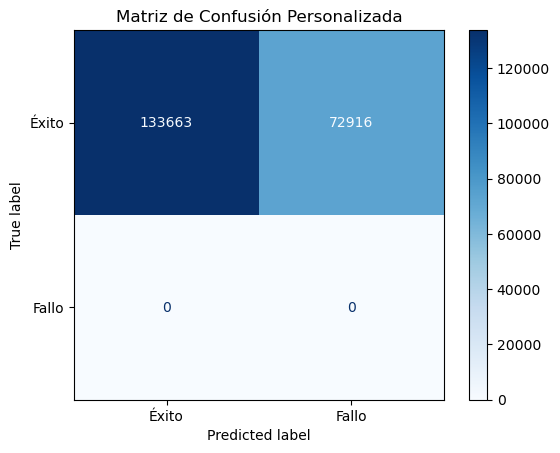

In [21]:
#df_usar_acum

var_objetivo="_ Matricula detalle para analisis.Calif Final _ Retiros"
col_usar=["_ Matricula detalle para analisis.repitencia profesor referencia","Nombre_Programa","_ Matricula detalle para analisis.Prof_Codigo","_ Matricula detalle para analisis.pga inicial","_ Matricula detalle para analisis.prom semestral t_1","_ Matricula detalle para analisis.Sexo","_ Matricula detalle para analisis.Asistencia CREE t_1","_ Matricula detalle para analisis.Procedencia Categoria","_ Matricula detalle para analisis.Edad cursan asignatura",'prom_prereq_nota_general','prom_prereq_intentos_general']

df_usar_acum,col_usar,var_objetivo=renombrar_columnas(df_usar_acum)

print(df_usar_acum.columns.values.tolist())

cols_to_category = [
    "programa",
    "sexo",
    "procedencia_categoria",
    "profesor_codigo",
    "asignatura",
    "Dpto_Asignatura"
]

df_usar_acum=cambiar_a_category(df_usar_acum, cols_to_category)


modelo, df_pred, metricas, X_train, X_test = entrenar_xgboost_regresion(
    df=df_usar_acum,
    columna_objetivo=var_objetivo,
    columnas_predictores=col_usar
)

col_prediccion="Prediccion_XGB"

matriz_conf, df_pred= matriz_confusion_personalizada(df_pred, var_objetivo, col_prediccion, margen_error=0.3, graficar=True)


<Figure size 1000x600 with 0 Axes>

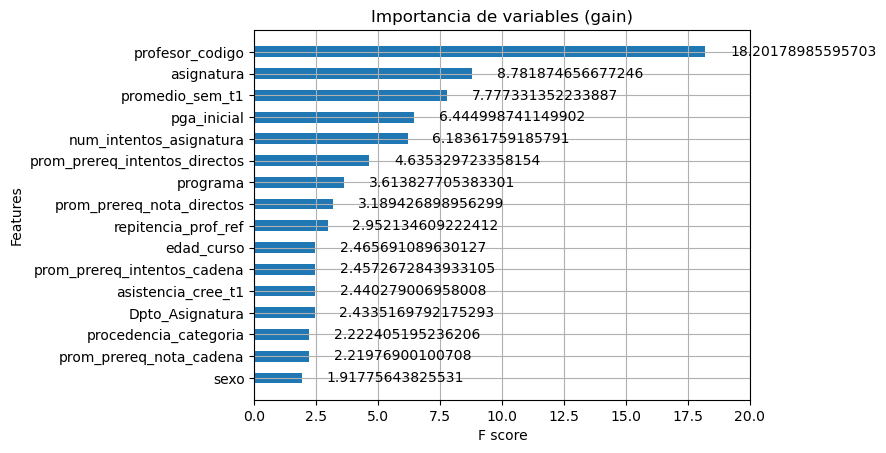

In [22]:
#mostrar_arbol(modelo, num_tree=0, ancho=1000, alto=600, orientacion="LR")
mostrar_importancia_gain(modelo, top_n=20)
#reporte_importancia(modelo)

📊 Generando summary plot global...


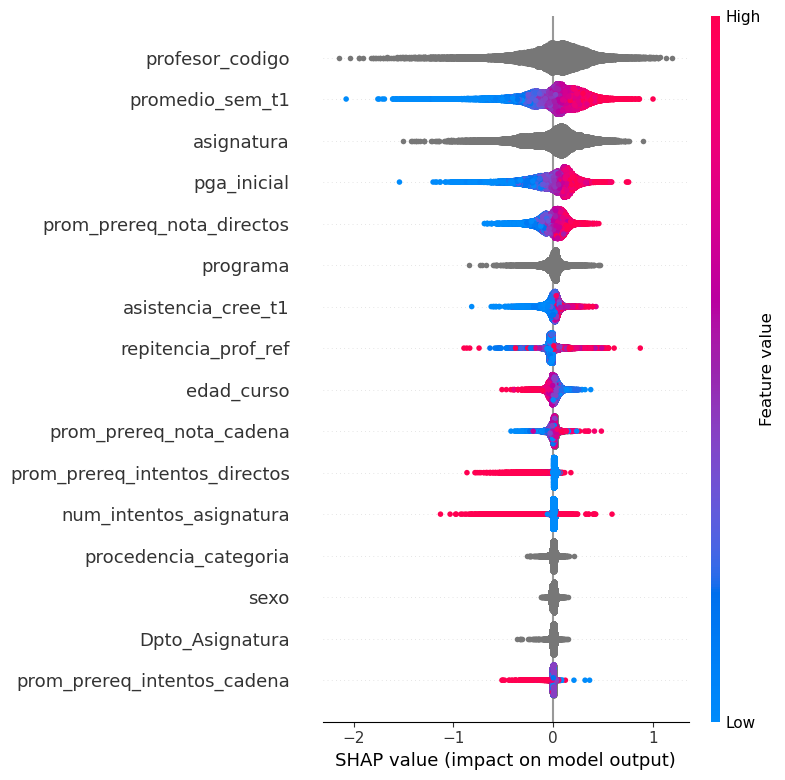


📊 Generando dependence plots para las 1 variables más importantes...

➡️ Dependence plot para variable: profesor_codigo


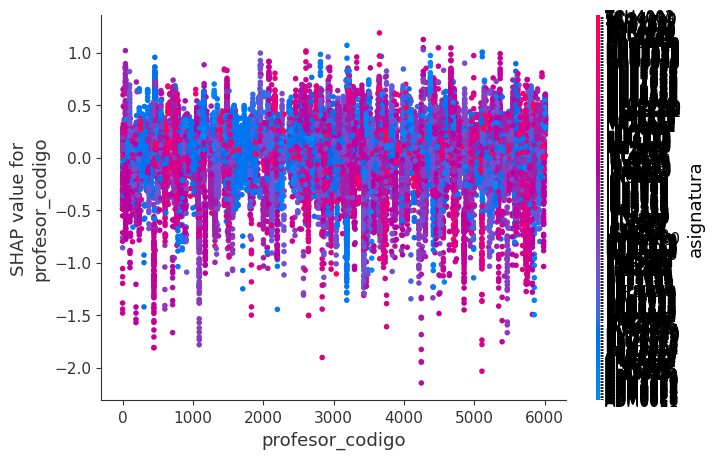

📌 Explicación de la predicción para el estudiante 0


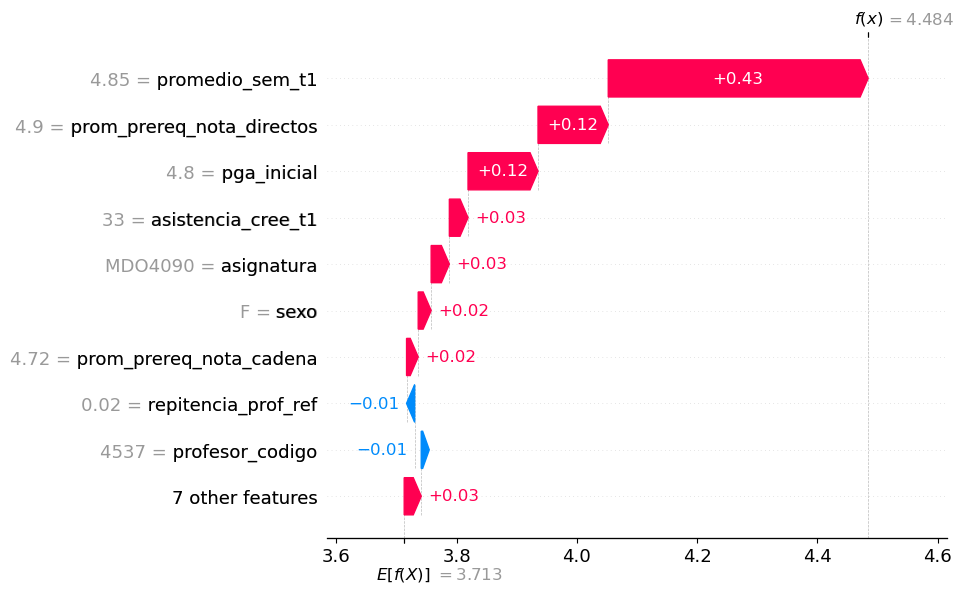

📌 Explicación de la predicción para el estudiante 1


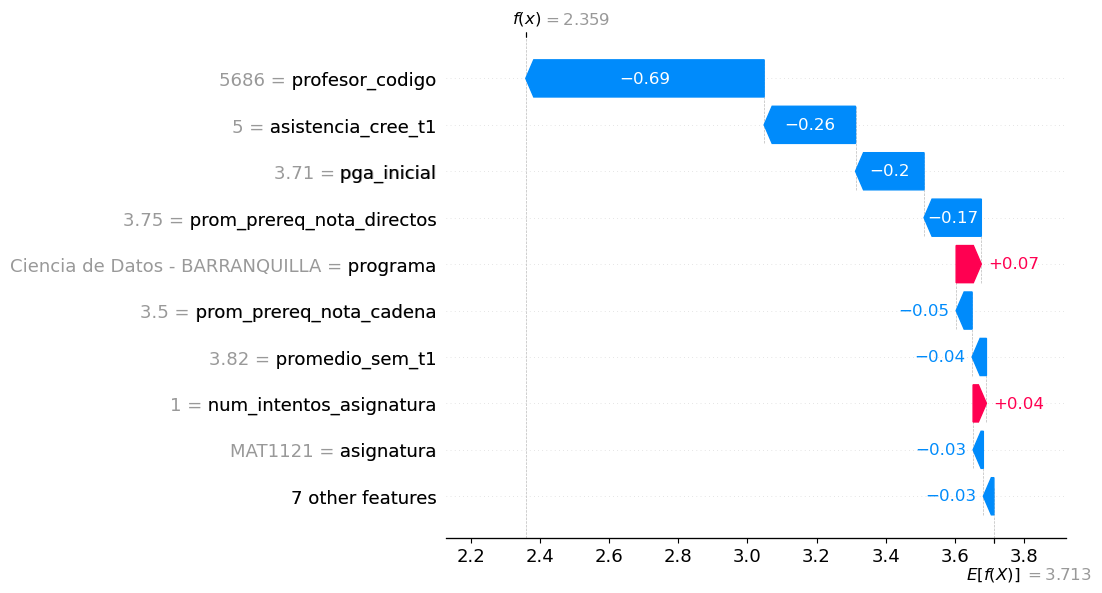

In [23]:
#interpretar_xgboost_shap(modelo, X_test, col_usar, top_n=10, id_check=0) 
interpretar_xgboost_shap(modelo, X_test, col_usar, top_n=1, id_check=0) 
gen_xboost_waterfall_plot(modelo, X_test, id_check=1)